In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('samplesuperstore.csv', encoding='latin-1')
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  US-2023-103800   1/3/2023   1/7/2023  Standard Class    DP-13000   
1       2  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
2       3  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
3       4  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
4       5  US-2023-141817   1/5/2023  1/12/2023  Standard Class    MB-18085   

   Customer Name      Segment Country/Region          City  ... Postal Code  \
0  Darren Powers     Consumer  United States       Houston  ...       77095   
1  Phillina Ober  Home Office  United States    Naperville  ...       60540   
2  Phillina Ober  Home Office  United States    Naperville  ...       60540   
3  Phillina Ober  Home Office  United States    Naperville  ...       60540   
4     Mick Brown     Consumer  United States  Philadelphia  ...       19143   

    Region       Product ID         Category Sub-C

In [4]:
print("Shape:", df.shape)

Shape: (10194, 21)


In [5]:
print("\nColumns:", df.columns.tolist())


Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [6]:
print("\nNull values:\n", df.isnull().sum())


Null values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [7]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 0


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [9]:
print("Date column type:", df['Order Date'].dtype)

Date column type: datetime64[ns]


In [10]:
df['Year'] = df['Order Date'].dt.year

In [11]:
df['Month'] = df['Order Date'].dt.month

In [12]:
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

In [13]:
print(df[['Order Date', 'Year', 'Month', 'Quarter']].head())

  Order Date  Year  Month Quarter
0 2023-01-03  2023      1  2023Q1
1 2023-01-04  2023      1  2023Q1
2 2023-01-04  2023      1  2023Q1
3 2023-01-04  2023      1  2023Q1
4 2023-01-05  2023      1  2023Q1


In [14]:
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_revenue) * 100
total_orders = df['Order ID'].nunique()

print("Total Revenue  :", round(total_revenue, 2))
print("Total Profit   :", round(total_profit, 2))
print("Profit Margin  :", round(profit_margin, 2), "%")
print("Total Orders   :", total_orders)

Total Revenue  : 2326534.35
Total Profit   : 292296.81
Profit Margin  : 12.56 %
Total Orders   : 5111


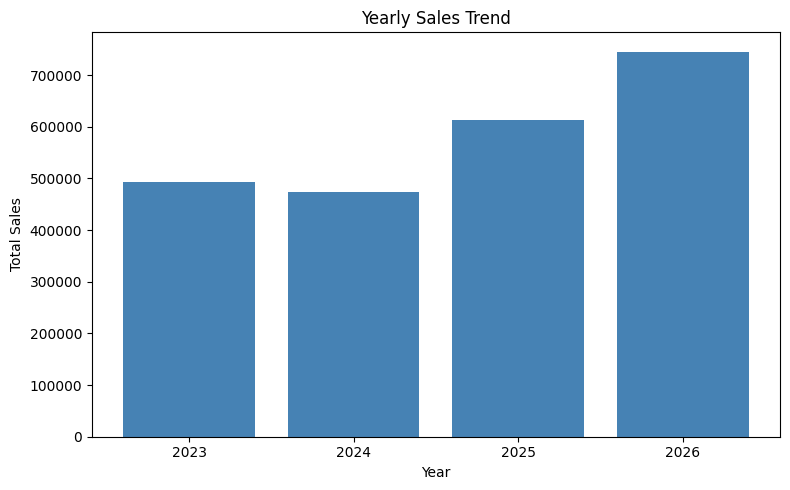

In [15]:
yearly = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(yearly['Year'].astype(str), yearly['Sales'], color='steelblue')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

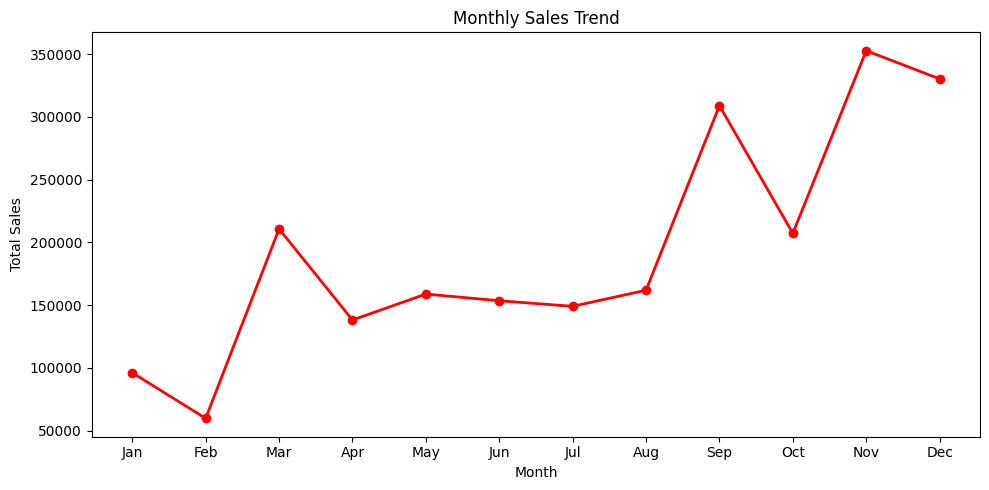

In [16]:
monthly = df.groupby('Month')['Sales'].sum().reset_index()

month_names = ['Jan','Feb','Mar','Apr','May',
               'Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 5))
plt.plot(month_names, monthly['Sales'], 
         marker='o', color='red', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

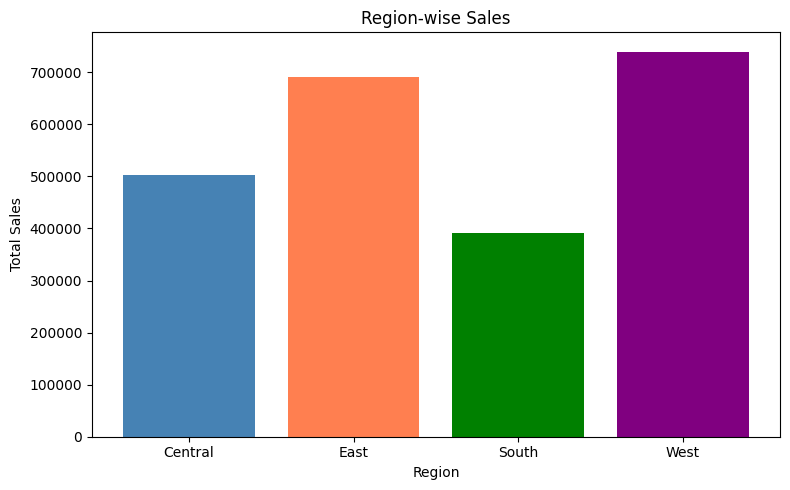

In [17]:
region = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(region['Region'], region['Sales'], 
        color=['steelblue','coral','green','purple'])
plt.title('Region-wise Sales')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

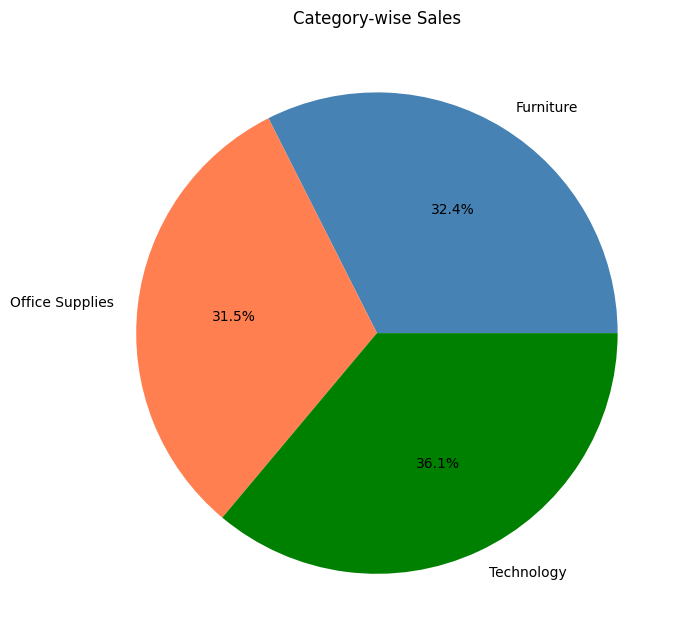

In [18]:
category = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(7, 7))
plt.pie(category, labels=category.index, 
        autopct='%1.1f%%',
        colors=['steelblue','coral','green'])
plt.title('Category-wise Sales')
plt.tight_layout()
plt.show()

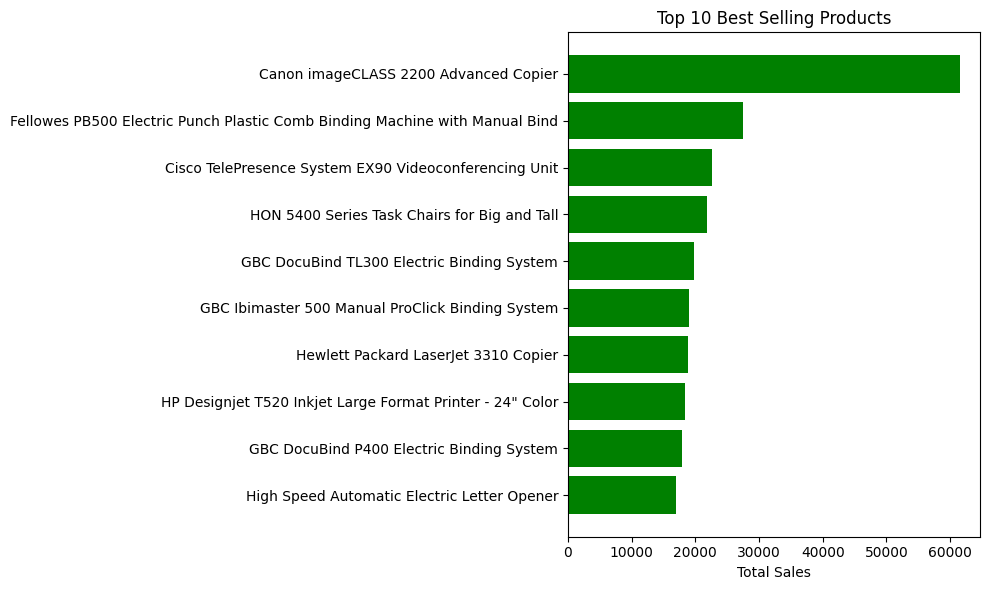

In [19]:
top10 = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10.index, top10.values, color='green')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Total Sales')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

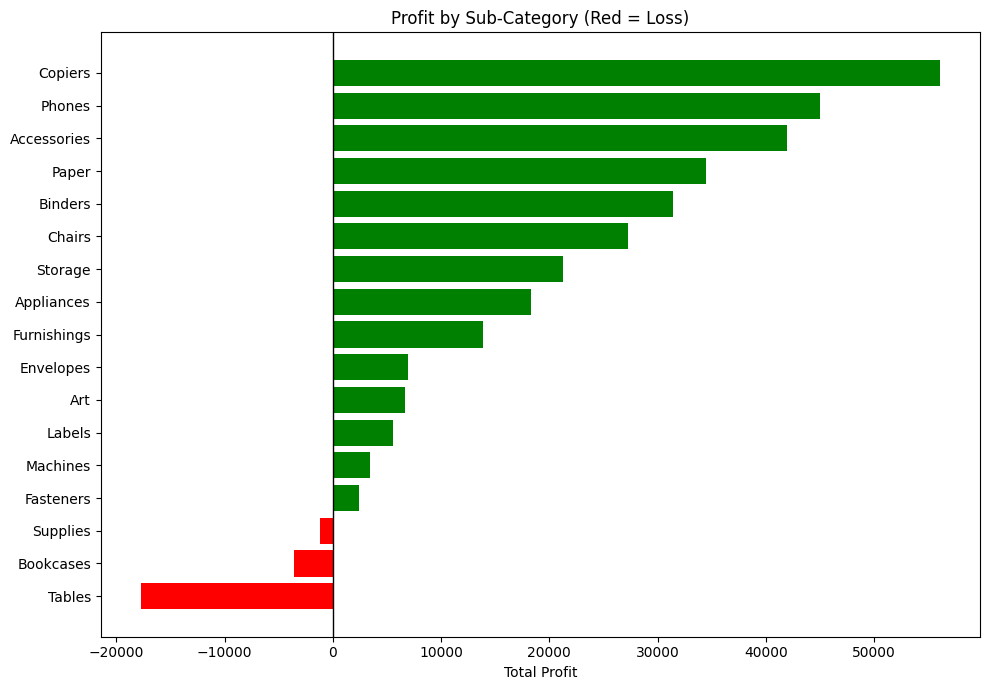

In [20]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

colors = ['red' if x < 0 else 'green' for x in sub_profit.values]

plt.figure(figsize=(10, 7))
plt.barh(sub_profit.index, sub_profit.values, color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Profit by Sub-Category (Red = Loss)')
plt.xlabel('Total Profit')
plt.tight_layout()
plt.show()

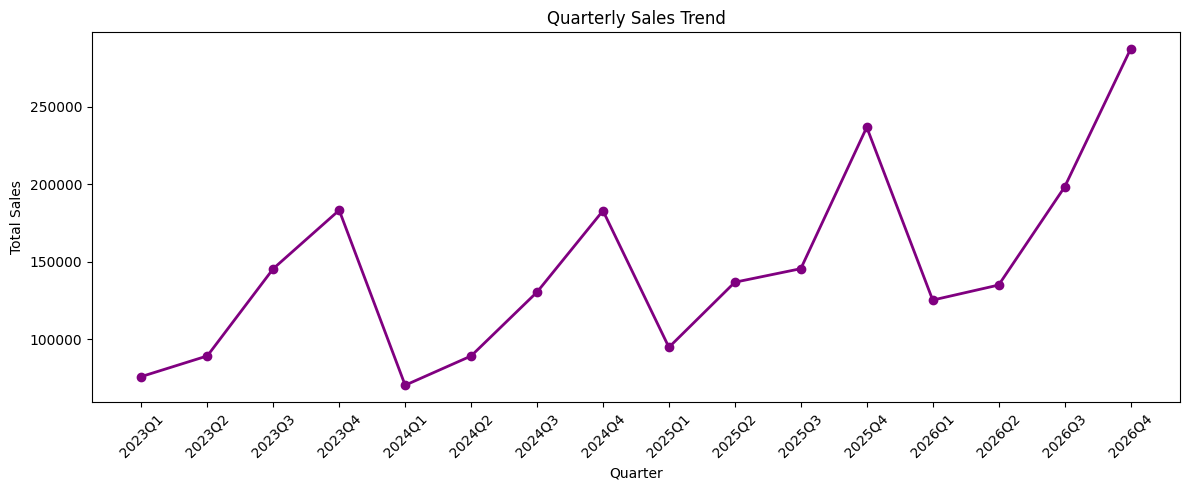

In [21]:
quarterly = df.groupby('Quarter')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(quarterly['Quarter'], quarterly['Sales'], 
         marker='o', color='purple', linewidth=2)
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
print("=" * 50)
print("   SALES PERFORMANCE DASHBOARD - SUMMARY")
print("=" * 50)
print(f"Total Revenue   : ${total_revenue:,.2f}")
print(f"Total Profit    : ${total_profit:,.2f}")
print(f"Profit Margin   : {profit_margin:.2f}%")
print(f"Total Orders    : {total_orders}")
print("-" * 50)
print("Best Category   : Technology")
print("Loss Category   : Tables, Bookcases")
print("Best Quarter    : Q4 (Every Year)")
print("Best Month      : November")
print("=" * 50)

   SALES PERFORMANCE DASHBOARD - SUMMARY
Total Revenue   : $2,326,534.35
Total Profit    : $292,296.81
Profit Margin   : 12.56%
Total Orders    : 5111
--------------------------------------------------
Best Category   : Technology
Loss Category   : Tables, Bookcases
Best Quarter    : Q4 (Every Year)
Best Month      : November
